# 07: Faithfulness: CBM vs Grad-CAM (Bonus)

Deletion / insertion metric (Petsiuk et al., 2018). CBM works at the 9-concept level, Grad-CAM at the pixel level.

In [1]:
import os, sys, yaml, logging
from pathlib import Path
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np, torch
from torch.utils.data import DataLoader, Subset

from src.data.datasets import build_dataset, default_collate
from src.data.transforms import baseline_eval_transform
from src.models.concept_predictor import load_concept_bundle, CONCEPT_IDS
from src.models.cbm_classifier import CBMLogisticRegression
from src.models.baseline_cnn import build_baseline, GradCAMExplainer
from src.evaluation.faithfulness import (
    cbm_deletion_insertion, gradcam_deletion_insertion, summarise_faithfulness,
)
from src.visualization.plots import plot_faithfulness_curves
from src.utils import get_device, describe_device, dataloader_kwargs, seed_everything

logging.basicConfig(level=logging.INFO)
cfg = yaml.safe_load((PROJECT_ROOT / 'config.yaml').read_text())
paths = cfg['paths']
seed_everything(cfg.get('seed', 42))
device = get_device()
print('device:', describe_device(device))

device: mps (Apple arm64)


In [2]:
# CBM-side: concept-level deletion/insertion
cbm = CBMLogisticRegression.load(PROJECT_ROOT / paths['checkpoints_dir'] / 'cbm_lr.joblib')
bundle = load_concept_bundle(PROJECT_ROOT / paths['concept_vectors_dir'] / 'concepts_derm7pt.npz')

# Evaluate on a sample of 200 to keep compute low
N = min(200, len(bundle['diagnosis']))
cbm_result = cbm_deletion_insertion(
    cbm,
    concept_scores=bundle['concepts'][:N],
    diagnosis_true=bundle['diagnosis'][:N],
    steps=cfg['faithfulness']['cbm_steps'],
    mask_value=cfg['faithfulness']['mask_value'],
)
print('CBM faithfulness:', summarise_faithfulness(cbm_result))

CBM faithfulness: {'mean_deletion_auc': 0.2749281279804806, 'mean_insertion_auc': 0.32844265351382396, 'median_deletion_auc': 0.26568568663464653, 'median_insertion_auc': 0.2807698274652163, 'faithfulness_score': 0.05351452553334335}


In [3]:
# Grad-CAM side: pixel-level deletion/insertion on a small eval set
arch = cfg['baseline']['architectures'][0]   # EfficientNet-B0
ckpt = PROJECT_ROOT / paths['checkpoints_dir'] / f'{arch}.pt'
loader_kwargs = dataloader_kwargs(device=device)

gc_result = None
if ckpt.exists():
    model = build_baseline(arch).to(device)
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state['state_dict'])
    model.eval()

    ds = build_dataset('ham10000',
                       root=PROJECT_ROOT / paths['datasets']['ham10000'],
                       transform=baseline_eval_transform(cfg['baseline']['image_size']))
    # Use a tiny random subset (say 32) for compute
    n_sub = min(32, len(ds))
    idx = np.random.default_rng(cfg['seed']).choice(len(ds), size=n_sub, replace=False)
    loader = DataLoader(Subset(ds, idx), batch_size=8, shuffle=False,
                        collate_fn=default_collate, **loader_kwargs)
    explainer = GradCAMExplainer(model, device=device)

    all_imgs, all_cams = [], []
    for batch in loader:
        imgs = batch['image']
        cams = explainer.explain(imgs, target_class=1)
        all_imgs.append(imgs); all_cams.append(cams)
    imgs_t = torch.cat(all_imgs, dim=0)
    cams = np.concatenate(all_cams, axis=0)
    gc_result = gradcam_deletion_insertion(
        model, imgs_t, cams,
        steps=cfg['faithfulness']['pixel_steps'],
        device=device,
    )
    print('Grad-CAM faithfulness:', summarise_faithfulness(gc_result))
else:
    print(f'[skip] {ckpt} missing; train baseline first')

Grad-CAM faithfulness: {'mean_deletion_auc': 0.05364805944814793, 'mean_insertion_auc': 0.20265777131346718, 'median_deletion_auc': 0.010376454830397959, 'median_insertion_auc': 0.09300257905771789, 'faithfulness_score': 0.14900971186531925}


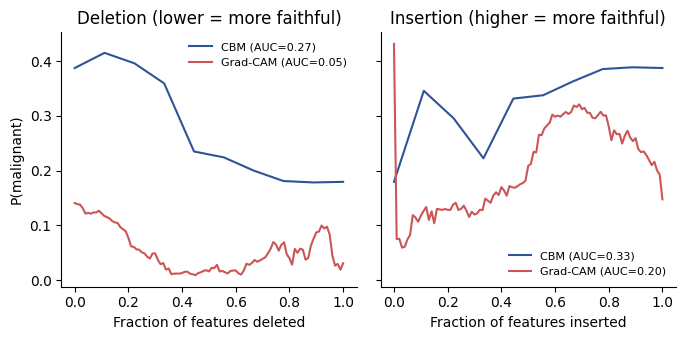

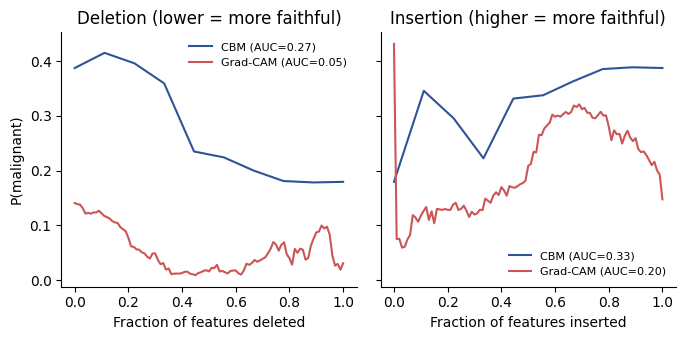

In [4]:
# Figure 7
plot_faithfulness_curves(cbm_result, gc_result,
                         out_dir=PROJECT_ROOT / paths['figures_dir'])